# Снижение размерности матриц текстов

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import numpy as np

In [ ]:
import re

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD

In [ ]:
import nltk

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import Counter

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Мы будем работать с тем же датасетом, что и в прошлый раз.

In [ ]:
from sklearn.datasets import fetch_20newsgroups

Пока что загрузим только тренировочный сабсет:

In [ ]:
newsgroups = fetch_20newsgroups(subset='train')

In [ ]:
list(newsgroups.target_names)

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

In [ ]:
# как выглядит один текст
newsgroups.data[100]

"From: tchen@magnus.acs.ohio-state.edu (Tsung-Kun Chen)\nSubject: ** Software forsale (lots) **\nNntp-Posting-Host: magnusug.magnus.acs.ohio-state.edu\nOrganization: The Ohio State University\n    ****   This is a post for my friend,  You can either call    ****\n    ****    him  J.K Lee  (614)791-0748    or Drop me a mail     ****\nDistribution: usa\nLines: 39\n\n1.  Software publishing SuperBase 4 windows v.1.3           --->$80\n\n2.  OCR System ReadRight v.3.1 for Windows                  --->$65\n\n3.  OCR System ReadRight  v.2.01 for DOS                    --->$65\n\n4.  Unregistered Zortech 32 bit C++ Compiler v.3.1          --->$ 250\n     with Multiscope windows Debugger,\n     WhiteWater Resource Toolkit, Library Source Code\n\n5.  Glockenspiel/ImageSoft Commonview 2 Windows\n     Applications Framework for Borland C++                 --->$70\n\n6.  Spontaneous Assembly Library With Source Code           --->$50\n\n7.  Microsoft Macro Assembly 6.0                            -

In [ ]:
len(newsgroups.data)

11314

In [ ]:
len(list(set(newsgroups.target)))

20

Сделаем небольшой препроцессинг путем лемматизации и удаления стоп-слов:

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocess_text(text):

  # Токенизация
  tokens = word_tokenize(text.lower())

  # Удаление стоп-слов и лемматизация
  processed_tokens = []
  for token in tokens:
    # удаляем короткие токены
    if token not in stop_words and len(token) > 2:
        lemma = lemmatizer.lemmatize(token)
        processed_tokens.append(lemma)

  return ' '.join(processed_tokens)

In [ ]:
preprocessed_docs = [preprocess_text(doc) for doc in newsgroups.data]

In [ ]:
preprocessed_docs[100]

'tchen magnus.acs.ohio-state.edu tsung-kun chen subject software forsale lot nntp-posting-host magnusug.magnus.acs.ohio-state.edu organization ohio state university post friend either call j.k lee 614 791-0748 drop mail distribution usa line software publishing superbase window v.1.3 ocr system readright v.3.1 window ocr system readright v.2.01 do unregistered zortech bit c++ compiler v.3.1 250 multiscope window debugger whitewater resource toolkit library source code glockenspiel/imagesoft commonview window application framework borland c++ spontaneous assembly library source code microsoft macro assembly 6.0 microsoft window v.3.1 sdk documentation 125 microsoft foxpro v.2.0 10. wordperfect 5.0 developer toolkit 11. kedwell software databoss v.3.5 code generator 100 12. kedwell installboss v.2.0 installation generator 13. liant software c++/views v.2.1 window application framework source code 195 14. ibm os/2 2.0 developer toolkit 15. cbtree dos/windows library source code 120 16. sy

In [ ]:
n_features = 1000 # максимальное количество слов в матрице "документы х слова" (= top1000 частотных из всех в корпусе)
n_components = 7 # число тем в корпусе
n_top_words = 20 # порог частотности для визуализаций

Попробуем чуть более продвинутую конфигурацию TfidfVectorizer'а. В частности, ограничим размер словаря (max_features), а также будем игнорировать слишком редкие или слишком частотные слова (max_df и min_df).

Здесь и далее часть кода по https://github.com/nstsj/ML_for_NLP/blob/main/6_dimred/dimred_for_texts(LDA%2BLSA).ipynb.

In [ ]:
tf_vectorizer = TfidfVectorizer(max_df=0.7, min_df=5, # игнорируем слова,которые только в 5 документах или в 70% документов.
                                max_features=n_features,
                                # если бы у нас не было препроцессинга
                                #stop_words='english'
                                )

X_tf = tf_vectorizer.fit_transform(preprocessed_docs)

In [ ]:
X_tf.shape # матрица "документы x слова"

(11314, 1000)

## Визуализация с t-SNE

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
%%time
X_embedded = TSNE(n_components=2, init='random', perplexity=3).fit_transform(X_tf)

CPU times: user 2min 19s, sys: 4.21 s, total: 2min 23s
Wall time: 2min 24s


In [ ]:
X_embedded.shape

(11314, 2)

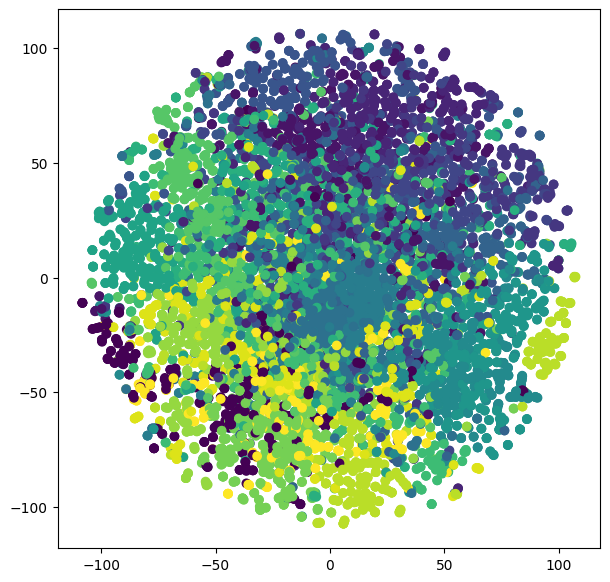

In [ ]:
fig, ax = plt.subplots(figsize=(7,7))
plt.scatter(X_embedded[:,0], X_embedded[:,1], c=newsgroups.target)
plt.show()

In [ ]:
%%time
X_embedded_30 = TSNE(n_components=2, init='random', perplexity=30).fit_transform(X_tf)

CPU times: user 2min 47s, sys: 1.65 s, total: 2min 48s
Wall time: 2min 50s


In [ ]:
X_embedded_30.shape

(11314, 2)

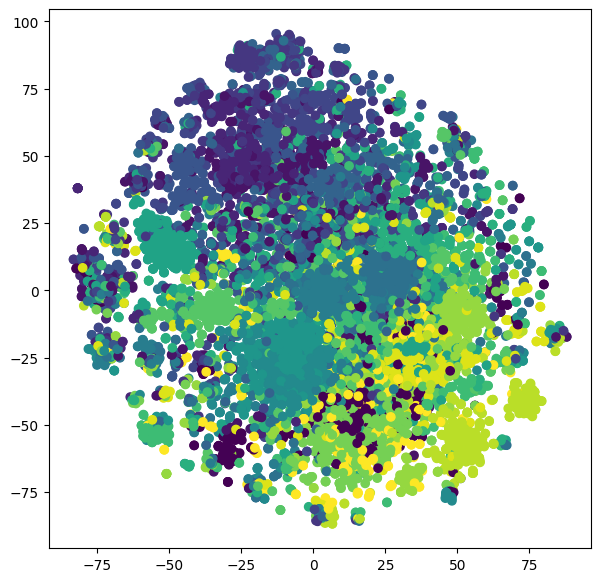

In [ ]:
fig, ax = plt.subplots(figsize=(7,7))
plt.scatter(X_embedded_30[:,0], X_embedded_30[:,1], c=newsgroups.target)
plt.show()

## LSA (Latent Semantic Analysis)

Метод главных компонент в sklearn не работает с разреженными матрицами, поэтому для текстов рекомендуется использовать латентно-семантический анализ при помощи класса TruncatedSVD.

In [ ]:
lsa_model = TruncatedSVD(n_components=100, n_iter=10)

lsa_topic_matrix = lsa_model.fit_transform(X_tf)

In [ ]:
# матрица тем
lsa_topic_matrix.shape

(11314, 100)

Видно, что вторая компонента объясняет больше всего дисперсии (хотя тоже очень мало):

In [ ]:
lsa_model.explained_variance_ratio_

array([0.01250675, 0.01382647, 0.01079252, 0.00896565, 0.00854963,
       0.00708316, 0.00656074, 0.00625634, 0.00595898, 0.00569221,
       0.00532084, 0.00525854, 0.00502767, 0.00499085, 0.00470299,
       0.00460246, 0.00435067, 0.00424849, 0.00422758, 0.00406864,
       0.00391409, 0.0038929 , 0.0038187 , 0.00379971, 0.00373191,
       0.00364757, 0.00363829, 0.00353538, 0.00352154, 0.00349826,
       0.00343909, 0.00338818, 0.00336364, 0.00329937, 0.00329042,
       0.00325514, 0.00322017, 0.00317588, 0.00313912, 0.00309781,
       0.00307622, 0.00300525, 0.00296988, 0.00293941, 0.00291773,
       0.00286941, 0.00286078, 0.00283322, 0.00281754, 0.00278767,
       0.00277707, 0.00274712, 0.00272699, 0.00270649, 0.00266033,
       0.00265471, 0.00264434, 0.00260038, 0.00258264, 0.00256119,
       0.00254288, 0.0025317 , 0.00251613, 0.00251159, 0.0025006 ,
       0.00246914, 0.00245714, 0.00241352, 0.0023911 , 0.00237958,
       0.00236822, 0.00234878, 0.00233178, 0.00232375, 0.00230

Всего 100 компонент объясняют 34% дисперсии:

In [ ]:
np.sum(lsa_model.explained_variance_ratio_)

np.float64(0.347498659097874)

Попробуем посмотреть, какие слова входят в конкретную компоненту.

np.argsort() возвращает индексы для сортировки массива, но в обратном порядке (т.е. слова с самыми большими значениями будут в конце отсортированного массива). Мы возьмем последние N самых значимых слов.

In [ ]:
lsa_model.components_[0].shape

(1000,)

In [ ]:
top_features_ind = lsa_model.components_[0].argsort()[:-n_top_words - 1:-1]

In [ ]:
top_features_ind

array([996, 314, 873, 627, 141, 114, 612, 413, 225, 971, 123, 942, 867,
       448, 635, 174, 583, 183, 127, 416])

Теперь возьмем слова, находящиеся в списке признаков под этими индексами.

In [ ]:
tf_feature_names = tf_vectorizer.get_feature_names_out()

top_features = [tf_feature_names[i] for i in top_features_ind]

Посмотрим на самые значимые слова и их веса:

In [ ]:
weights = lsa_model.components_[0][top_features_ind]

In [ ]:
list(zip(top_features, weights))

[('you', np.float64(0.2205516456941058)),
 ('edu', np.float64(0.19859922225055437)),
 ('this', np.float64(0.1531764164676204)),
 ('on', np.float64(0.15017323551952122)),
 ('be', np.float64(0.14948956882417083)),
 ('are', np.float64(0.1492032588882175)),
 ('not', np.float64(0.14903851725218042)),
 ('have', np.float64(0.1457844658917493)),
 ('com', np.float64(0.14447406894369128)),
 ('with', np.float64(0.1334232133943923)),
 ('as', np.float64(0.1332108856409568)),
 ('was', np.float64(0.12773670547886298)),
 ('they', np.float64(0.12654108162701527)),
 ('if', np.float64(0.12059030440807991)),
 ('or', np.float64(0.1200133154467645)),
 ('but', np.float64(0.1159944783890526)),
 ('my', np.float64(0.10611301599583983)),
 ('can', np.float64(0.10597425441556525)),
 ('at', np.float64(0.09900197774586753)),
 ('he', np.float64(0.09805111713691023))]

Эти слова и их веса можно отрисовать как бар-чарт:

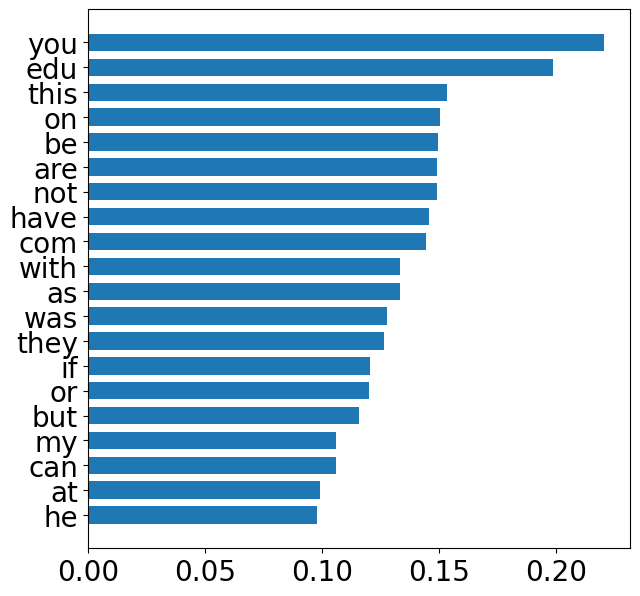

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.barh(top_features, weights, height=0.7)
ax.invert_yaxis()
ax.tick_params(axis='both', which='major', labelsize=20)

Такие графики можно отрисовать, например, для первых семи топиков:

In [ ]:
def plot_top_words(model, feature_names, n_top_words, title, n_components, max_plots=7):

    fig, axes = plt.subplots(1, max_plots, figsize=(25, 10)) # параметры отображения
    axes = axes.flatten()
    all_features = {} # словарь для сохранения ключевых слов для тем


    for topic_idx, topic in enumerate(model.components_):
      if topic_idx < max_plots:
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]

        # строка для сохранения темы и слов в словарь
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f'Topic {topic_idx +1}',
                     fontdict={'fontsize': 13})
        ax.invert_yaxis()
        ax.tick_params(axis='both', which='major', labelsize=10)
        for i in 'top right left'.split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=14)


    plt.show()

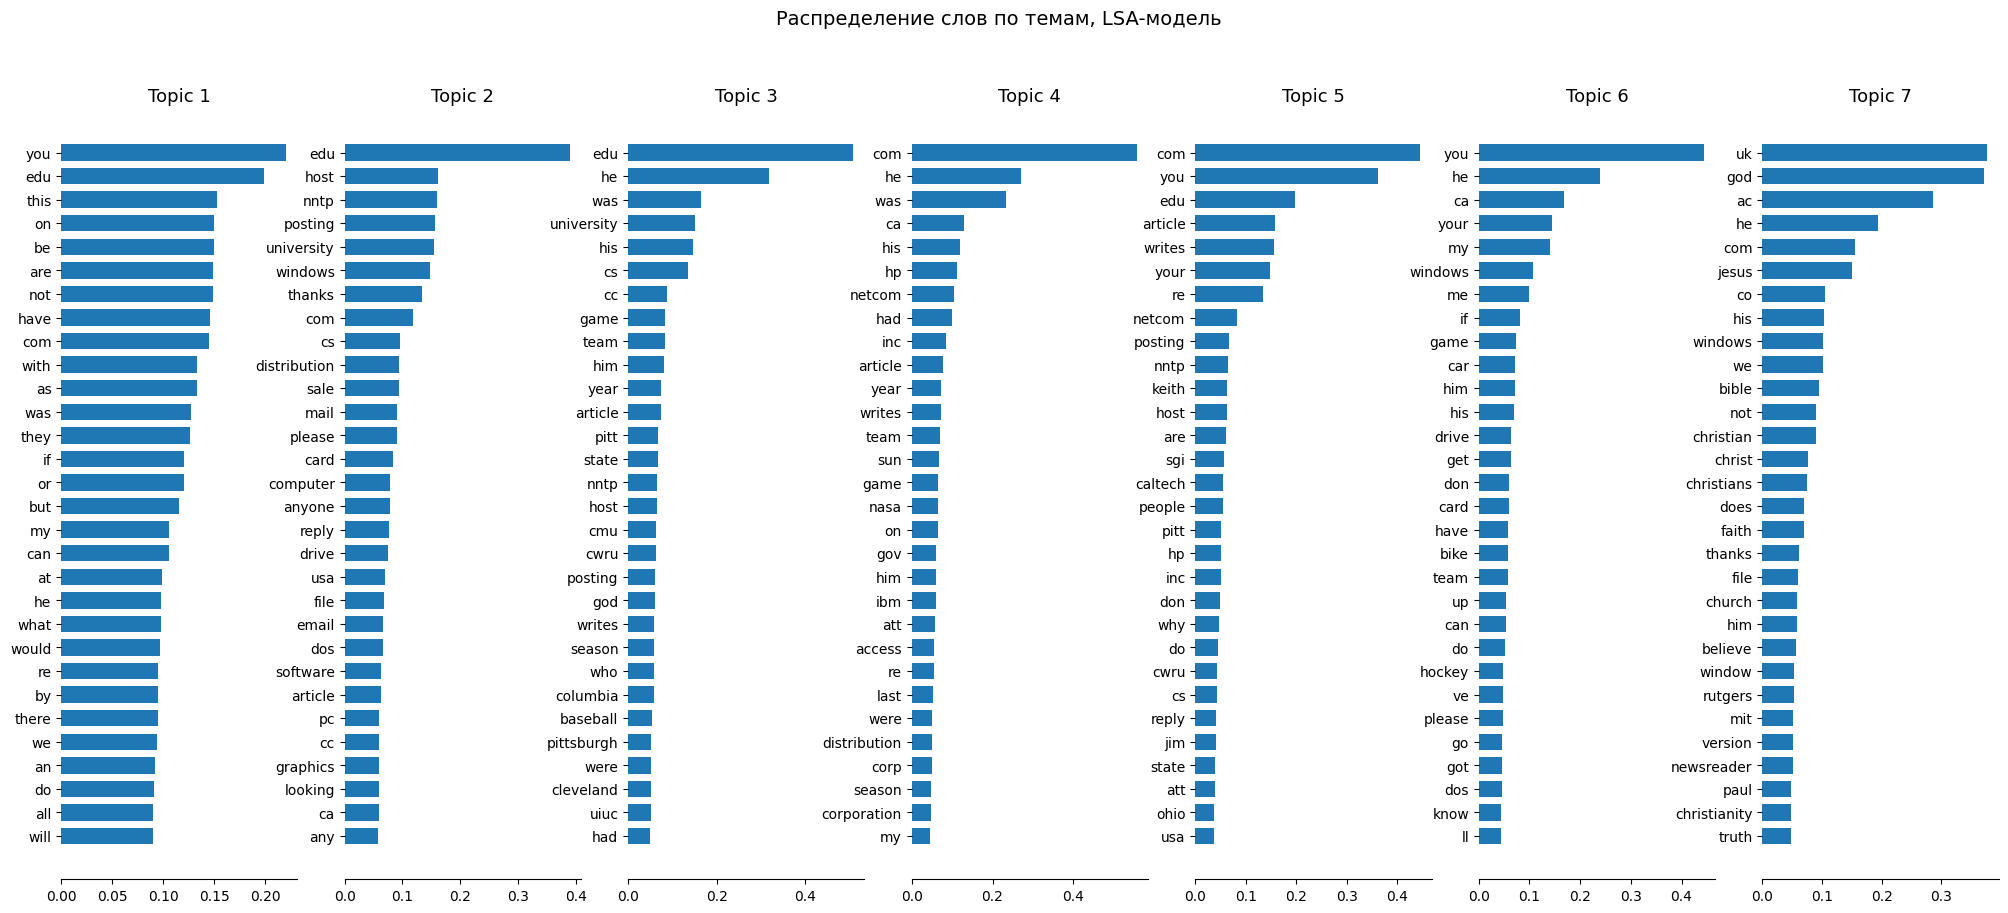

In [ ]:
tf_feature_names = tf_vectorizer.get_feature_names_out()
plot_top_words(lsa_model, tf_feature_names, 30, 'Распределение слов по темам, LSA-модель', n_components)

Можно посмотреть, к какому топику принадлежит каждый документ:

In [ ]:
for n in range(10):
    topic_most_pr = lsa_topic_matrix[n].argmax()
    print("doc: {} topic: {}\n".format(n,topic_most_pr))

doc: 0 topic: 0

doc: 1 topic: 0

doc: 2 topic: 0

doc: 3 topic: 0

doc: 4 topic: 0

doc: 5 topic: 0

doc: 6 topic: 0

doc: 7 topic: 14

doc: 8 topic: 0

doc: 9 topic: 0



## LDA (Latent Dirichlet Allocation)

In [ ]:
lda = LatentDirichletAllocation(n_components=100)

lda.fit(X_tf)

LatentDirichletAllocation(n_components=100)

In [ ]:
# матрица "темы x слова": с какой вероятностью каждая тема генерирует каждое слово в корпусе
lda.components_

array([[0.01      , 0.01      , 0.01      , ..., 0.01      , 0.01      ,
        0.01      ],
       [0.01      , 0.01      , 0.01      , ..., 0.01      , 0.01      ,
        0.01      ],
       [0.01      , 0.01      , 0.01      , ..., 0.01      , 0.01      ,
        0.01      ],
       ...,
       [0.60236954, 0.01      , 3.36678083, ..., 0.01      , 0.01      ,
        0.01      ],
       [0.01      , 0.01      , 0.01      , ..., 0.01      , 0.01      ,
        0.01      ],
       [0.01      , 0.01      , 0.01      , ..., 0.13506246, 0.01      ,
        0.01      ]])

Можно посмотреть на распределение документов по темам:

In [ ]:
# ряды - id документов, колонки - id топиков, ячейки - вероятность отнесения документа к топику.
doc_topic = lda.transform(X_tf)

In [ ]:
doc_topic.shape

(11314, 100)

In [ ]:
# ряды - id документов, колонки - id топиков, ячейки - вероятность отнесения документа к топику.
pd.DataFrame(doc_topic).head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.001476,0.001476,0.001476,0.001476,0.001476,0.001476,0.001476,0.001476,0.001476,0.001476,...,0.001476,0.001476,0.001476,0.001476,0.001476,0.001476,0.001476,0.001476,0.001476,0.001476
1,0.001505,0.001505,0.001505,0.001505,0.001505,0.001505,0.001505,0.001505,0.001505,0.001505,...,0.001505,0.001505,0.001505,0.001505,0.001505,0.001505,0.001505,0.001505,0.001505,0.001505
2,0.000936,0.000936,0.000936,0.000936,0.000936,0.000936,0.000936,0.000936,0.000936,0.000936,...,0.000936,0.000936,0.000936,0.000936,0.000936,0.000936,0.000936,0.000936,0.000936,0.000936
3,0.001253,0.001253,0.001253,0.001253,0.001253,0.001253,0.001253,0.001253,0.001253,0.001253,...,0.001253,0.001253,0.001253,0.001253,0.001253,0.001253,0.001253,0.001253,0.001253,0.001253
4,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,...,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216,0.001216


In [ ]:
def plot_top_words(model, feature_names, n_top_words, title, n_components, max_plots=7):

    fig, axes = plt.subplots(1, max_plots, figsize=(25, 10)) # параметры отображения
    axes = axes.flatten()
    all_features = {} # словарь для сохранения ключевых слов для тем


    for topic_idx, topic in enumerate(model.components_):
      if topic_idx < max_plots:
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]

        # строка для сохранения темы и слов в словарь
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f'Topic {topic_idx +1}',
                     fontdict={'fontsize': 13})
        ax.invert_yaxis()
        ax.tick_params(axis='both', which='major', labelsize=10)
        for i in 'top right left'.split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=14)


    plt.show()

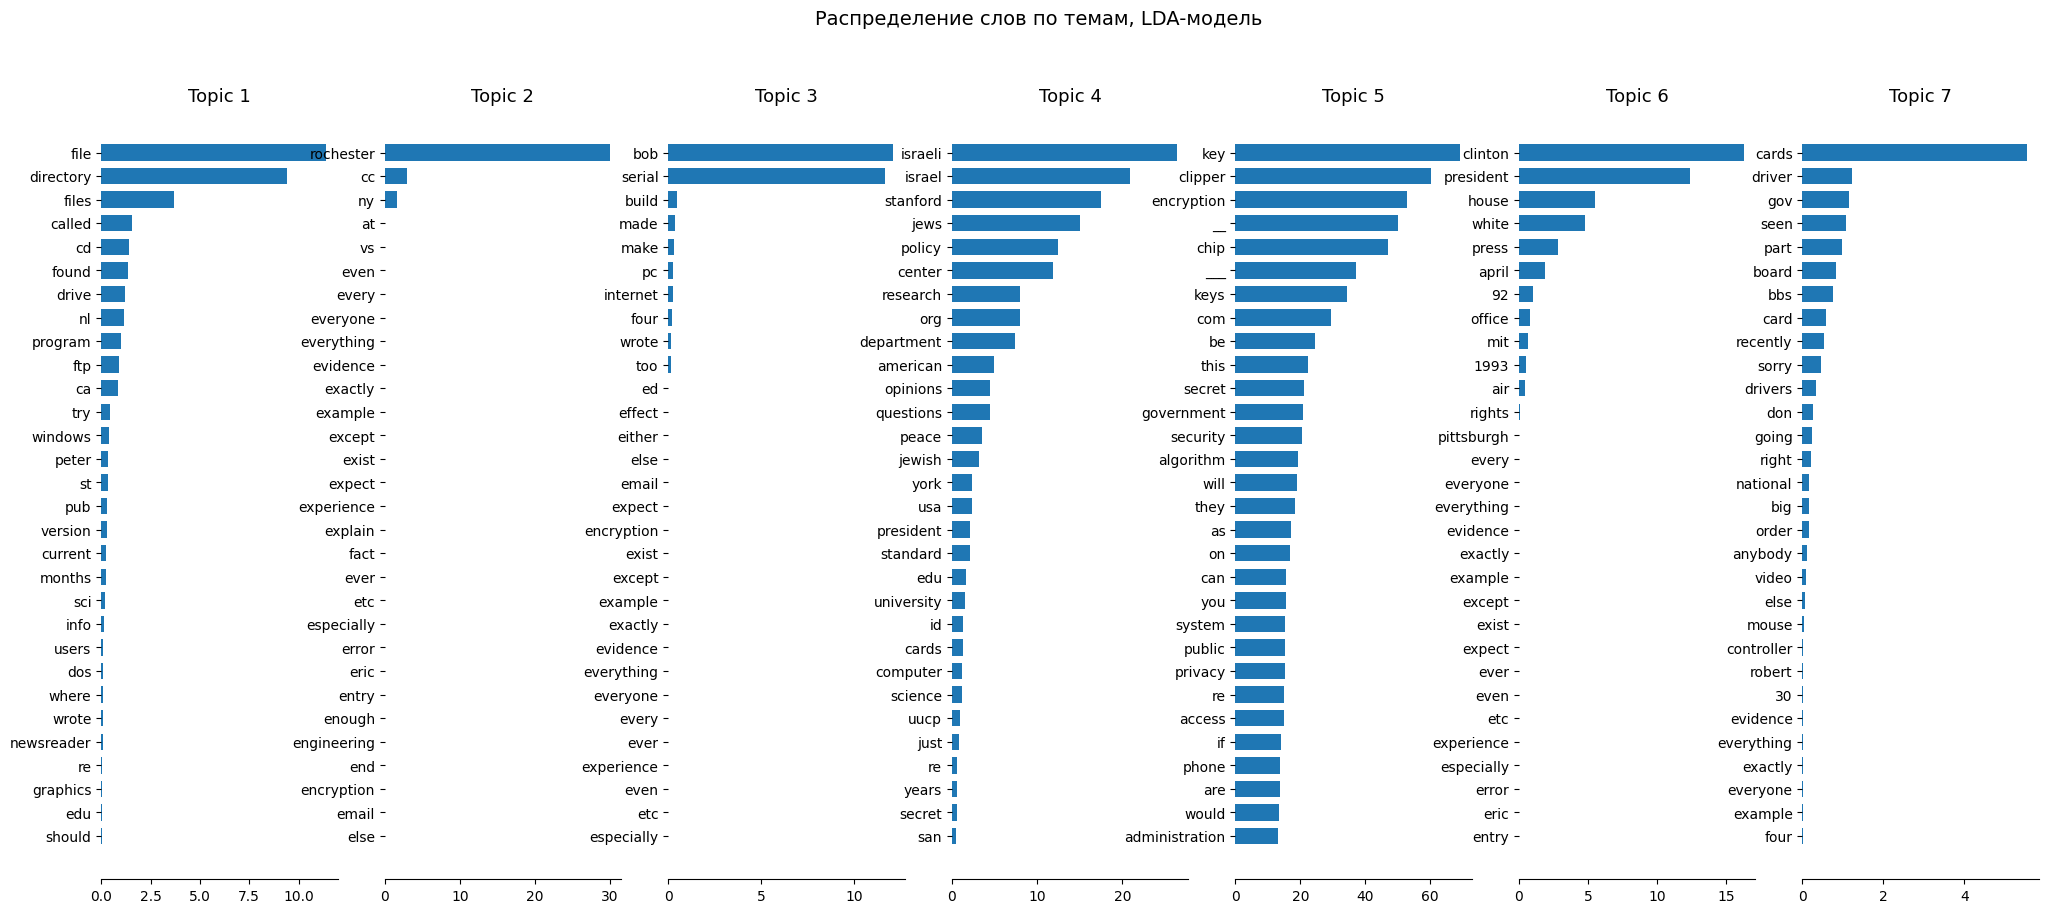

In [ ]:
plot_top_words(lda, tf_feature_names, 30, 'Распределение слов по темам, LDA-модель', n_components)

Можно оценить перплексию и log likelihood модели на тестовых данных.

In [ ]:
test_data = fetch_20newsgroups(subset='test')

In [ ]:
X_test = [preprocess_text(doc) for doc in test_data.data]

In [ ]:
y_test = test_data.target

In [ ]:
X_test_vectors = tf_vectorizer.transform(X_test)

In [ ]:
lda.perplexity(X_test_vectors)

np.float64(10074.76694487686)

In [ ]:
lda.score(X_test_vectors)

np.float64(-373883.10130362125)

### Gensim

Куда более популярным инструментом для создания LDA-моделей для тематического моделирования является библиотека **gensim**. Давайте посмотрим, как она работает.

In [ ]:
# ! pip install gensim pyLDAvis

In [ ]:
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel

import pyLDAvis
import pyLDAvis.gensim

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Мы не будем пользоваться матрицей tf-idf, которую создавали изначально, но для честного сравнения библиотек нам нужно убедиться, что мы используем только те слова, которые в ней присутствуют:

In [ ]:
filtered_documents = []
unique_feature_names = set(tf_feature_names)

for doc in preprocessed_docs:
  tokens = doc.split()
  # используем только те токены, которые присутствуют в оригинальной tf-idf матрице
  filtered_tokens = [token for token in tokens if token in unique_feature_names]
  filtered_documents.append(filtered_tokens)

In [ ]:
id2word = corpora.Dictionary(filtered_documents)
corpus = [id2word.doc2bow(text) for text in filtered_documents]

id2word - словарь, в котором хранятся токены и их id:

In [ ]:
for i, (token, token_id) in enumerate(id2word.token2id.items()):
    if i >= 10:
        break
    print(f"  {token}: {token_id}")

  anyone: 0
  body: 1
  called: 2
  car: 3
  college: 4
  could: 5
  day: 6
  early: 7
  front: 8
  history: 9


Можно посмотреть на самые частотные слова в словаре:

In [ ]:
id2word.most_common(10)

[('line', 12929),
 ('would', 9540),
 ('one', 9271),
 ('writes', 7840),
 ('article', 7017),
 ('people', 6010),
 ('like', 5830),
 ('university', 5612),
 ('know', 5511),
 ('get', 5421)]

Теперь посмотрим, что внутри корпуса:

In [ ]:
for doc_idx, doc_bow in enumerate(corpus[:2]):
    print(f"Текст {doc_idx}:")
    # Переведем тексты из формата (id, частота)
    words_in_doc = [(word_id, id2word[word_id], freq) for word_id, freq in doc_bow]
    for word_id, word, freq in words_in_doc:
        print(f"id: {word_id}, слово: {word}, частота: {freq}")

Текст 0:
id: 0, слово: anyone, частота: 2
id: 1, слово: body, частота: 1
id: 2, слово: called, частота: 1
id: 3, слово: car, частота: 5
id: 4, слово: college, частота: 1
id: 5, слово: could, частота: 1
id: 6, слово: day, частота: 1
id: 7, слово: early, частота: 1
id: 8, слово: front, частота: 1
id: 9, слово: history, частота: 1
id: 10, слово: info, частота: 1
id: 11, слово: know, частота: 1
id: 12, слово: line, частота: 1
id: 13, слово: looking, частота: 1
id: 14, слово: made, частота: 1
id: 15, слово: model, частота: 1
id: 16, слово: name, частота: 1
id: 17, слово: please, частота: 1
id: 18, слово: really, частота: 1
id: 19, слово: rest, частота: 1
id: 20, слово: saw, частота: 1
id: 21, слово: small, частота: 1
id: 22, слово: thanks, частота: 1
id: 23, слово: thing, частота: 1
id: 24, слово: university, частота: 1
id: 25, слово: whatever, частота: 1
id: 26, слово: year, частота: 1
Текст 1:
id: 6, слово: day, частота: 2
id: 12, слово: line, частота: 1
id: 17, слово: please, частота: 2


In [ ]:
# можно видеть, что мы действительно получаем частотный список каждого документа
Counter(filtered_documents[0])

Counter({'thing': 1,
         'car': 5,
         'university': 1,
         'college': 1,
         'line': 1,
         'anyone': 2,
         'could': 1,
         'saw': 1,
         'day': 1,
         'early': 1,
         'called': 1,
         'really': 1,
         'small': 1,
         'front': 1,
         'rest': 1,
         'body': 1,
         'know': 1,
         'model': 1,
         'name': 1,
         'year': 1,
         'made': 1,
         'history': 1,
         'whatever': 1,
         'info': 1,
         'looking': 1,
         'please': 1,
         'thanks': 1})

In [ ]:
# больше о параметрах: https://radimrehurek.com/gensim/models/ldamodel.html
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                            id2word=id2word,
                                            num_topics=20,
                                            random_state=100,
                                            passes=10
                                            )

Можно получить самые значимые слова для каждого топика:

In [ ]:
topics = lda_model.print_topics(num_words=10)
for topic in topics:
  print(topic)

(0, '0.088*"writes" + 0.076*"article" + 0.072*"line" + 0.039*"university" + 0.035*"science" + 0.030*"computer" + 0.019*"distribution" + 0.015*"david" + 0.015*"technology" + 0.014*"institute"')
(1, '0.073*"line" + 0.047*"university" + 0.045*"thanks" + 0.042*"please" + 0.031*"anyone" + 0.030*"know" + 0.026*"would" + 0.025*"help" + 0.020*"distribution" + 0.019*"email"')
(2, '0.041*"car" + 0.027*"line" + 0.021*"new" + 0.019*"price" + 0.018*"sale" + 0.018*"bike" + 0.017*"good" + 0.013*"cost" + 0.012*"like" + 0.012*"buy"')
(3, '0.049*"israel" + 0.044*"new" + 0.042*"israeli" + 0.038*"research" + 0.037*"center" + 0.030*"state" + 0.023*"1993" + 0.023*"university" + 0.022*"april" + 0.022*"york"')
(4, '0.093*"window" + 0.024*"application" + 0.024*"problem" + 0.024*"display" + 0.023*"using" + 0.022*"server" + 0.019*"program" + 0.019*"color" + 0.018*"use" + 0.018*"widget"')
(5, '0.449*"max" + 0.108*"a86" + 0.104*"145" + 0.098*"b8f" + 0.062*"1d9" + 0.056*"2di" + 0.047*"bhj" + 0.036*"giz" + 0.016*"ai

Также из объекта модели можно легко узнать perplexity:

In [ ]:
lda_model.log_perplexity(corpus)

np.float64(-5.956774702988844)

Для определения coherence потребуется специальный класс CoherenceModel:

In [ ]:
coherence_model_lda = CoherenceModel(model=lda_model, texts=filtered_documents, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print(coherence_lda)

0.5640095379029948


In [ ]:
dominant_topics = [max(lda_model.get_document_topics(doc), key=lambda x: x[1])[0] for doc in corpus]

Можно попробовать переделать TSNE-визуализацию векторов документов, покрасив их в цвета тем из LDA:

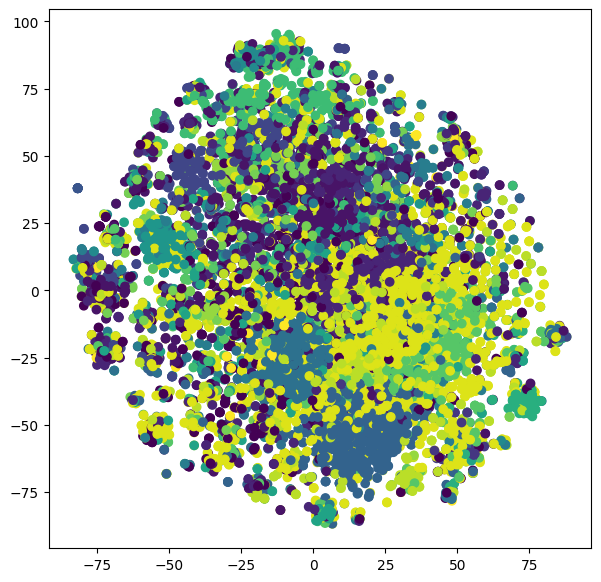

In [ ]:
# NB! Помните, что в таком случае порядок документов в коллекции не должен меняться!
fig, ax = plt.subplots(figsize=(7,7))
plt.scatter(X_embedded_30[:,0], X_embedded_30[:,1], c=dominant_topics)
plt.show()

Наконец, сделаем интерактивную визуализацию при помощи библиотеки pyLDAvis:

In [ ]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model,
                              corpus,
                              id2word,
                              # как уменьшить размерность данных для отрисовки. Другие варианты: pcoa, tsne
                              mds="mmds",
                              # сколько слов показывать для каждого топика
                              R=30
                              )
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
18     0.011648 -0.046553       1        1  18.318500
6      0.079339  0.008029       2        1   9.101054
17     0.101167 -0.145239       3        1   8.785094
14    -0.023790  0.064153       4        1   6.868546
8      0.216540  0.000410       5        1   5.953227
2     -0.060970 -0.116571       6        1   5.459100
0     -0.188945 -0.206688       7        1   4.741137
1     -0.224620  0.162111       8        1   4.736171
15     0.101596  0.347341       9        1   4.735333
7      0.103019 -0.239050      10        1   4.052758
4      0.328277  0.096411      11        1   3.735999
13    -0.023082  0.292435      12        1   3.707780
12     0.206689  0.097282      13        1   3.222603
10    -0.127578  0.331272      14        1   3.128084
16     0.242634  0.270707      15        1   2.961276
11    -0.258506 -0.145488      16        1   2.860435
3     -0.410574 -0.055144      17        1   2.717052
9     -0.314944  0.171364      18        1   1.750037
19     0.339788 -0.292064      19        1   1.693292
5     -0.097690 -0.594719      20        1   1.472521, topic_info=        Term          Freq         Total Category  logprob  loglift
603      max   4779.000000   4779.000000  Default  30.0000  30.0000
128   writes   7824.000000   7824.000000  Default  29.0000  29.0000
109  article   6952.000000   6952.000000  Default  28.0000  28.0000
12      line  12867.000000  12867.000000  Default  27.0000  27.0000
194     file   2786.000000   2786.000000  Default  26.0000  26.0000
..       ...           ...           ...      ...      ...      ...
754      75u      0.061678     11.689973  Topic20 -12.0585  -1.0264
536      cut      0.061678    466.772348  Topic20 -12.0585  -4.7135
222      may      0.061678   3265.338364  Topic20 -12.0585  -6.6588
315    water      0.061678    414.750640  Topic20 -12.0585  -4.5953
170     john      0.061678   1408.811617  Topic20 -12.0585  -5.8181

[933 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
724      11  0.967646    000
395       1  0.087599    100
395       3  0.005840    100
395       4  0.058399    100
395       5  0.114852    100
...     ...       ...    ...
316      11  0.034248  young
316      13  0.012087  young
316      16  0.020146  young
316      17  0.259880  young
316      19  0.038277  young

[4970 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[19, 7, 18, 15, 9, 3, 1, 2, 16, 8, 5, 14, 13, 11, 17, 12, 4, 10, 20, 6])

## Использование уменьшенных данных для других задач

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

In [ ]:
X_test_lsa = lsa_model.transform(X_test_vectors)
# берем lda из sklearn, т.к. оно удобнее, если нужно уменьшить размерность, а не анализировать топики
X_test_lda = lda.transform(X_test_vectors)

In [ ]:
X_train_lsa = lsa_topic_matrix
X_train_lda = doc_topic

In [ ]:
y_train = newsgroups.target

In [ ]:
knn.fit(X_train_lda, y_train)

KNeighborsClassifier()

In [ ]:
knn_preds = knn.predict(X_test_lda)

In [ ]:
print(classification_report(y_test, knn_preds, target_names=newsgroups.target_names))

                          precision    recall  f1-score   support

             alt.atheism       0.19      0.29      0.22       319
           comp.graphics       0.17      0.35      0.23       389
 comp.os.ms-windows.misc       0.21      0.21      0.21       394
comp.sys.ibm.pc.hardware       0.31      0.30      0.31       392
   comp.sys.mac.hardware       0.24      0.28      0.26       385
          comp.windows.x       0.29      0.32      0.31       395
            misc.forsale       0.43      0.63      0.51       390
               rec.autos       0.23      0.23      0.23       396
         rec.motorcycles       0.30      0.26      0.28       398
      rec.sport.baseball       0.40      0.46      0.43       397
        rec.sport.hockey       0.53      0.38      0.44       399
               sci.crypt       0.69      0.53      0.60       396
         sci.electronics       0.20      0.17      0.18       393
                 sci.med       0.14      0.11      0.12       396
         

In [ ]:
knn_2 = KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn_2.fit(X_train_lsa, y_train)

KNeighborsClassifier()

In [ ]:
knn_2_preds = knn_2.predict(X_test_lsa)

In [ ]:
print(classification_report(y_test, knn_2_preds, target_names=newsgroups.target_names))

                          precision    recall  f1-score   support

             alt.atheism       0.31      0.30      0.31       319
           comp.graphics       0.23      0.38      0.29       389
 comp.os.ms-windows.misc       0.07      0.26      0.10       394
comp.sys.ibm.pc.hardware       0.41      0.35      0.38       392
   comp.sys.mac.hardware       0.43      0.38      0.40       385
          comp.windows.x       0.32      0.51      0.39       395
            misc.forsale       0.34      0.66      0.45       390
               rec.autos       0.54      0.35      0.42       396
         rec.motorcycles       0.63      0.35      0.45       398
      rec.sport.baseball       0.42      0.30      0.35       397
        rec.sport.hockey       0.60      0.58      0.59       399
               sci.crypt       0.75      0.49      0.59       396
         sci.electronics       0.22      0.13      0.16       393
                 sci.med       0.40      0.09      0.14       396
         

In [ ]:
cm = confusion_matrix(y_test, knn_2_preds)

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

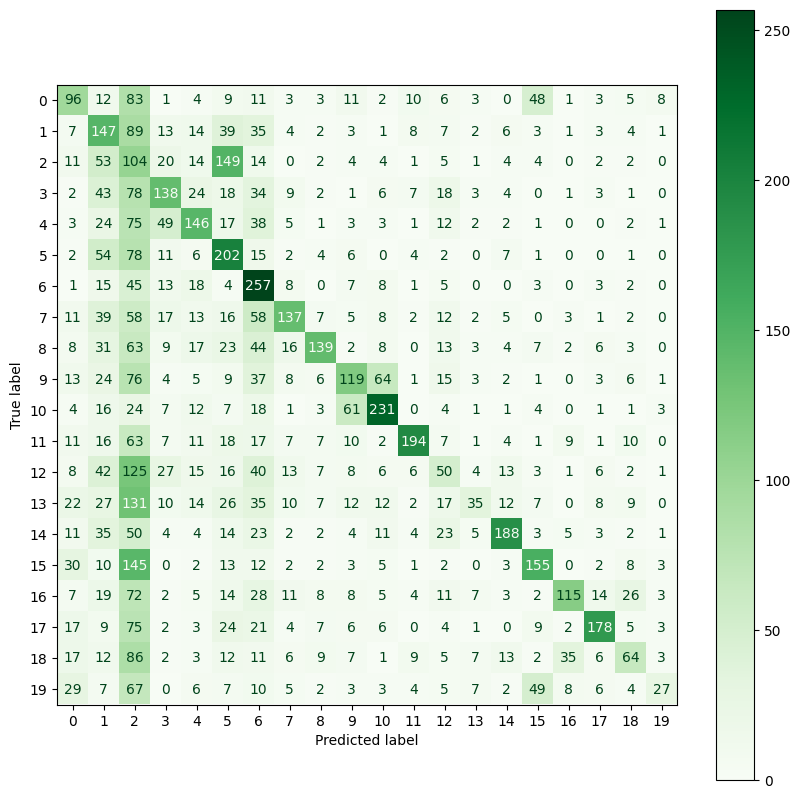

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Greens, ax=ax)
plt.show()

In [ ]:
[(n, topic) for n, topic in enumerate(newsgroups.target_names)]

[(0, 'alt.atheism'),
 (1, 'comp.graphics'),
 (2, 'comp.os.ms-windows.misc'),
 (3, 'comp.sys.ibm.pc.hardware'),
 (4, 'comp.sys.mac.hardware'),
 (5, 'comp.windows.x'),
 (6, 'misc.forsale'),
 (7, 'rec.autos'),
 (8, 'rec.motorcycles'),
 (9, 'rec.sport.baseball'),
 (10, 'rec.sport.hockey'),
 (11, 'sci.crypt'),
 (12, 'sci.electronics'),
 (13, 'sci.med'),
 (14, 'sci.space'),
 (15, 'soc.religion.christian'),
 (16, 'talk.politics.guns'),
 (17, 'talk.politics.mideast'),
 (18, 'talk.politics.misc'),
 (19, 'talk.religion.misc')]

Посмотрим, побивают ли эти результаты модель, обученную на полной матрице векторов:

In [ ]:
knn_baseline = KNeighborsClassifier(n_neighbors=5)

In [ ]:
knn_baseline.fit(X_tf, y_train)

KNeighborsClassifier()

In [ ]:
knn_baseline_preds = knn_baseline.predict(X_test_vectors)

In [ ]:
print(classification_report(y_test, knn_baseline_preds, target_names=newsgroups.target_names))

                          precision    recall  f1-score   support

             alt.atheism       0.39      0.50      0.44       319
           comp.graphics       0.26      0.51      0.34       389
 comp.os.ms-windows.misc       0.29      0.28      0.28       394
comp.sys.ibm.pc.hardware       0.33      0.43      0.37       392
   comp.sys.mac.hardware       0.43      0.43      0.43       385
          comp.windows.x       0.37      0.56      0.45       395
            misc.forsale       0.41      0.56      0.48       390
               rec.autos       0.55      0.41      0.47       396
         rec.motorcycles       0.60      0.56      0.58       398
      rec.sport.baseball       0.46      0.37      0.41       397
        rec.sport.hockey       0.59      0.67      0.63       399
               sci.crypt       0.72      0.60      0.66       396
         sci.electronics       0.43      0.30      0.35       393
                 sci.med       0.55      0.30      0.39       396
         